# 05 — Planteles y Métricas Per-90 (Rising Transfers)

**Fuentes:**
- `silver.stg_wc2026_squads` — 1,363 jugadores de los 48 planteles WC2026 con posición, edad, club y valor de mercado
- `silver.stg_wc2026_per90` — métricas por 90 minutos de la temporada 2025-26 para 1,181 jugadores
- `gold.mart_player_scouting` — tabla combinada StatsBomb + Rising Transfers para scouting avanzado

**Origen:** Rising Transfers (CC BY 4.0). Carga única en el pipeline — los planteles no cambian
una vez iniciado el torneo.

**Estructura del notebook:**
1. Carga de datos y verificación de cobertura  
2. Auditoría de nulos (pocos, esperados)  
3. Composición de planteles — distribución de posiciones  
4. Distribución de edades — perfil generacional por equipo  
5. Valor de mercado total por plantel  
6. Ranking de jugadores por métricas per-90  
7. Cobertura cruzada con StatsBomb (mart_player_scouting)  
8. Hallazgos y limitaciones  

**Qué nos dice este notebook sobre el torneo:**
El valor de mercado del plantel es el mejor proxy disponible de la "calidad total" de un equipo.
Las métricas per-90 muestran qué jugadores están en mejor momento de forma antes del torneo.
Combinado con el xG histórico (notebook 04), permite entender si un equipo tiene los jugadores
adecuados para ejecutar su estilo de juego en WC2026.

**Limitación:** las métricas per-90 no incluyen xG propio (solo goles y disparos como proxy).
El xG por jugador está disponible en `mart_player_scouting` (StatsBomb), pero solo para los
247 jugadores del plantel WC2026 que jugaron en WC2022, Copa América 2024 o Euro 2020/2024.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import query, null_report

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.max_columns', None)

## 1. Carga de datos

In [2]:
squads = query("SELECT * FROM silver.stg_wc2026_squads ORDER BY team_name, position, player_name")

# per90 hace SELECT * del Bronze — columnas dependen del CSV de Rising Transfers
# Inspeccionamos primero para saber qué existe
per90_cols = query("""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_schema = 'silver' AND table_name = 'stg_wc2026_per90'
    ORDER BY ordinal_position
""")
print("Columnas disponibles en stg_wc2026_per90:")
print(per90_cols['column_name'].tolist())

# Cargar sin asumir columnas específicas
per90 = query("SELECT * FROM silver.stg_wc2026_per90")

scout = query("SELECT * FROM gold.mart_player_scouting LIMIT 200")

print(f"\nstg_wc2026_squads:          {squads.shape}")
print(f"stg_wc2026_per90:           {per90.shape}")
print(f"mart_player_scouting (200): {scout.shape}")

Columnas disponibles en stg_wc2026_per90:
['player_id', 'player_name', 'slug', 'season', 'minutes', 'goals_per90', 'assists_per90', 'shots_per90', 'key_passes_per90', 'tackles_per90', 'interceptions_per90', 'clearances_per90', 'passes_per90', 'pass_accuracy_pct', 'saves_per90', 'rating']

stg_wc2026_squads:          (1363, 10)
stg_wc2026_per90:           (1181, 16)
mart_player_scouting (200): (200, 34)


In [3]:
squads.head(3)

,player_id_rt,player_name,rt_slug,team_name,team_code,position,club,age,market_value_eur,competition_slug
0,95635,Aïssa Mandi,a-mandi,Algeria,DZA,DF,LOSC Lille,34.0,6480000.0,wc2026
1,37530791,Jaouen Hadjam,j-hadjam,Algeria,DZA,DF,Young Boys,23.0,2835000.0,wc2026
2,37543437,Mehdi Dorval,e-dorval,Algeria,DZA,DF,Bari 1908,25.0,3255000.0,wc2026


In [4]:
per90.head(3)

,player_id,player_name,slug,season,minutes,goals_per90,assists_per90,shots_per90,key_passes_per90,tackles_per90,interceptions_per90,clearances_per90,passes_per90,pass_accuracy_pct,saves_per90,rating
0,261,Junior Hoilett,d-hoilett,2025-26,722,0.125,0.249,0.620,1.750,1.990,1.000,0.620,28.170,64.2,0.0,NaN
1,268,Luka Modrić,l-modri,2025-26,2816,0.064,0.096,0.639,1.694,1.662,1.246,1.055,70.920,90.4,0.0,7.33
2,323,Jordan Henderson,j-henderson,2025-26,1921,0.047,0.141,0.281,0.890,1.265,0.796,1.687,54.253,77.9,0.0,6.70


## 2. Reporte de nulos

In [5]:
print("=== stg_wc2026_squads ===")
display(null_report(squads))

print("\n=== stg_wc2026_per90 ===")
display(null_report(per90))

=== stg_wc2026_squads ===


,nulos,pct,dtype
market_value_eur,46,3.4,float64
club,8,0.6,str
age,7,0.5,float64



=== stg_wc2026_per90 ===


,nulos,pct,dtype
rating,48,4.1,float64
pass_accuracy_pct,21,1.8,float64


## 3. Composición de planteles — distribución de posiciones

FIFA amplió los planteles a 26 jugadores para WC2026 (antes 23). Esto se refleja en la
media de 28.4 jugadores por equipo — algunos equipos llevaron más jugadores.

**Lo que esperamos ver:** la distribución global debe reflejar la estructura táctica
típica de equipos modernos con 3-4 porteros, ~8 defensas, ~8 mediocampistas y ~6-7 delanteros.
Variaciones por equipo revelan preferencias tácticas (equipos con más mediocampistas → estilo
posesión; más delanteros → juego directo).

Los códigos de posición en Rising Transfers son: `GK`, `DF`, `MF`, `FW` (no nombres expandidos).

In [6]:
print("Valores únicos de posición:")
print(squads['position'].value_counts())

# Posiciones en Rising Transfers usan códigos cortos: GK / DF / MF / FW
pos_map = {
    'GK': 'GK',
    'DF': 'DEF',
    'MF': 'MID',
    'FW': 'FWD',
}

squads['pos_group'] = squads['position'].map(pos_map).fillna('OTR')

pos_count = squads['pos_group'].value_counts()
print("\nDistribución general:", pos_count.to_dict())

print(f"\nJugadores totales: {len(squads)}")
print(f"Equipos únicos:    {squads['team_name'].nunique()}")
print(f"Media por equipo:  {len(squads)/squads['team_name'].nunique():.1f}")

Valores únicos de posición:
position
DF    439
FW    404
MF    375
GK    145
Name: count, dtype: int64

Distribución general: {'DEF': 439, 'FWD': 404, 'MID': 375, 'GK': 145}

Jugadores totales: 1363
Equipos únicos:    48
Media por equipo:  28.4


## 4. Distribución de edades — perfil generacional por equipo

La edad del plantel es un indicador de si un equipo está en una generación de oro
(media baja → en ascenso), en su pico (media 26-28) o en transición (media alta → veteranos).

**Gráfico izquierda:** histograma de edad de todos los 1,363 jugadores. La distribución normal
centrada en ~26-27 años confirma que los datos son razonables y no hay valores anómalos.

**Gráfico derecha:** los 10 equipos más jóvenes y los 10 más veteranos. Los equipos de África
y Asia tienden a ser más jóvenes (menor promedio de ligas top); los europeos suelen tener
veteranos experimentados. Un equipo muy joven puede sorprender pero también tener menos
experiencia en torneos de presión máxima.

Columna edad: age
count    1356.0
mean       27.3
std         4.3
min        17.0
25%        24.0
50%        27.0
75%        30.0
max        44.0
Name: age, dtype: float64


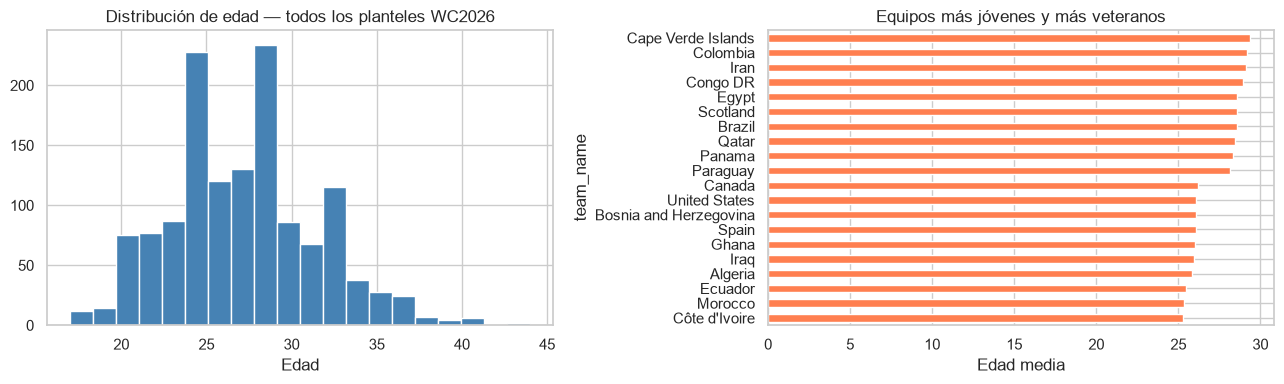

In [7]:
age_col = 'age' if 'age' in squads.columns else [c for c in squads.columns if 'age' in c.lower()][0]

print(f"Columna edad: {age_col}")
print(squads[age_col].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

squads[age_col].dropna().hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de edad — todos los planteles WC2026')
axes[0].set_xlabel('Edad')

# Edad media por equipo (top/bottom 10)
edad_equipo = squads.groupby('team_name')[age_col].mean().sort_values()
top_bot = pd.concat([edad_equipo.head(10), edad_equipo.tail(10)])
top_bot.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Equipos más jóvenes y más veteranos')
axes[1].set_xlabel('Edad media')

plt.tight_layout()
plt.show()

## 5. Valor de mercado total por plantel — proxy de calidad agregada

El valor de mercado (en millones de €, fuente: Transfermarkt via Rising Transfers) es el
mejor proxy disponible de la calidad total del plantel cuando no se tienen ratings por partidos
previos de todos los equipos.

**Lectura del gráfico:** los equipos con plantel más valioso son generalmente los que tienen
más jugadores en las ligas top europeas (Premier League, La Liga, Bundesliga, Serie A).
Los equipos de África y Asia tienen planteles menos valorados por el mercado pero esto
no necesariamente se traduce en peor rendimiento en el campo.

**Uso potencial en el modelo:** el valor de mercado podría usarse como feature adicional
para ajustar el λ de fallback de los 14 equipos Capa 2. Un equipo con plantel de €300M
debería tener un λ superior al global de 1.30 aunque no tenga datos StatsBomb.
Esta mejora está anotada como trabajo futuro en el pipeline.

Columnas de valor de mercado: ['market_value_eur']


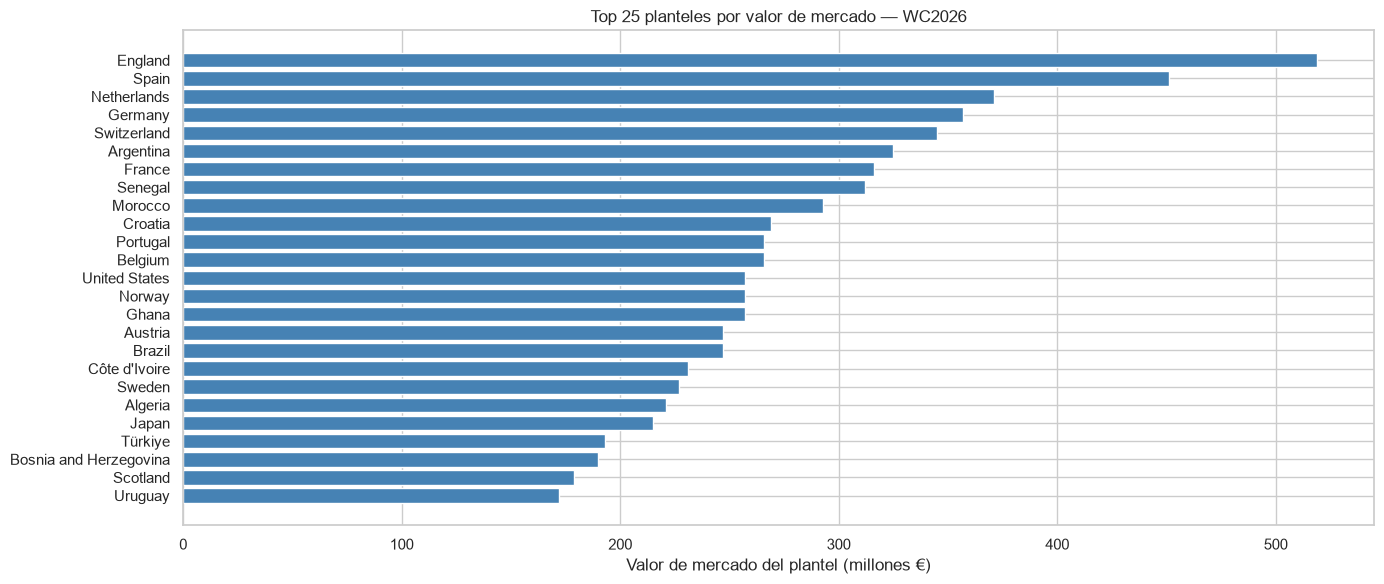

In [8]:
mkt_col = [c for c in squads.columns if 'market' in c.lower() or 'value' in c.lower()]
print("Columnas de valor de mercado:", mkt_col)

if mkt_col:
    mkt = mkt_col[0]
    valor_equipo = (squads.groupby('team_name')[mkt]
        .sum()
        .sort_values(ascending=False)
        .reset_index())
    valor_equipo.columns = ['equipo', 'valor_total_eur']
    valor_equipo['valor_M'] = (valor_equipo['valor_total_eur'] / 1e6).round(0)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.barh(valor_equipo['equipo'].head(25), valor_equipo['valor_M'].head(25), color='steelblue')
    ax.set_xlabel('Valor de mercado del plantel (millones €)')
    ax.set_title('Top 25 planteles por valor de mercado — WC2026')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró columna de valor de mercado en squads")

## 6. Top jugadores por métricas per-90 — ¿quiénes están en mejor forma?

Las métricas per-90 normalizan el rendimiento por tiempo jugado, lo que permite comparar
jugadores con minutos muy distintos (un titular de 2,500 min vs. un suplente de 400 min).

**Tres métricas de interés para el modelo:**
- `goals_per90`: proxy de xG para jugadores sin datos StatsBomb. Limitación: incluye penales,
  tiros de suerte y no incluye goles anulados por VAR — menos robusto que el xG real.
- `shots_per90`: volumen ofensivo. Un delantero que dispara 5 veces/90 genera más oportunidades
  que uno que dispara 2 veces/90, aunque su calidad individual sea similar.
- `key_passes_per90`: capacidad creadora. Mide los pases que directamente generaron un disparo,
  útil para identificar mediocampistas que alimentan el ataque del equipo.

**Los tres gráficos** muestran los top 15 por cada métrica con su equipo entre paréntesis.
Los jugadores de equipos CONMEBOL/UEFA dominan los rankings por calidad de liga, pero
algunos jugadores de Africa/Asia aparecen por tener métricas per-90 elevadas en menos minutos.

In [9]:
print("Columnas per90:", per90.columns.tolist())

Columnas per90: ['player_id', 'player_name', 'slug', 'season', 'minutes', 'goals_per90', 'assists_per90', 'shots_per90', 'key_passes_per90', 'tackles_per90', 'interceptions_per90', 'clearances_per90', 'passes_per90', 'pass_accuracy_pct', 'saves_per90', 'rating']


In [10]:
# per90 no tiene team_name ni xG — join con squads para enriquecer
# Deduplicar squads por player_name para evitar filas duplicadas por homónimos entre equipos
squads_dedup = squads.drop_duplicates(subset=['player_name'], keep='first')

per90_enriched = per90.merge(
    squads_dedup[['player_name', 'team_name', 'position', 'pos_group']],
    on='player_name',
    how='left'
)

n_matched = per90_enriched['team_name'].notna().sum()
n_unmatched = per90_enriched['team_name'].isna().sum()
print(f"Jugadores per90 con team_name tras JOIN: {n_matched}/{len(per90)} "
      f"({n_matched/len(per90)*100:.1f}%)")
print(f"Sin match (nombre distinto entre fuentes): {n_unmatched}")
if n_unmatched > 0:
    print("Sin match (muestra):",
          per90_enriched[per90_enriched['team_name'].isna()]['player_name'].head(10).tolist())
print()

# Métricas disponibles (no hay xG — usar goals_per90 y shots_per90 como proxy)
print("Columnas métricas en per90:")
metric_cols = ['goals_per90', 'assists_per90', 'shots_per90', 'key_passes_per90',
               'tackles_per90', 'interceptions_per90', 'passes_per90', 'pass_accuracy_pct',
               'saves_per90', 'rating']
metric_cols = [c for c in metric_cols if c in per90.columns]
print(metric_cols)
print()
print(per90[metric_cols].describe().round(2))

Jugadores per90 con team_name tras JOIN: 1181/1181 (100.0%)
Sin match (nombre distinto entre fuentes): 0

Columnas métricas en per90:
['goals_per90', 'assists_per90', 'shots_per90', 'key_passes_per90', 'tackles_per90', 'interceptions_per90', 'passes_per90', 'pass_accuracy_pct', 'saves_per90', 'rating']

       goals_per90  assists_per90  shots_per90  key_passes_per90  \
count      1181.00        1181.00      1181.00           1181.00   
mean          0.16           0.11         1.31              0.96   
std           0.20           0.13         1.10              0.78   
min           0.00           0.00         0.00              0.00   
25%           0.00           0.00         0.47              0.30   
50%           0.09           0.08         1.02              0.85   
75%           0.25           0.18         2.01              1.42   
max           1.36           0.92         6.10              4.24   

       tackles_per90  interceptions_per90  passes_per90  pass_accuracy_pct  \
coun

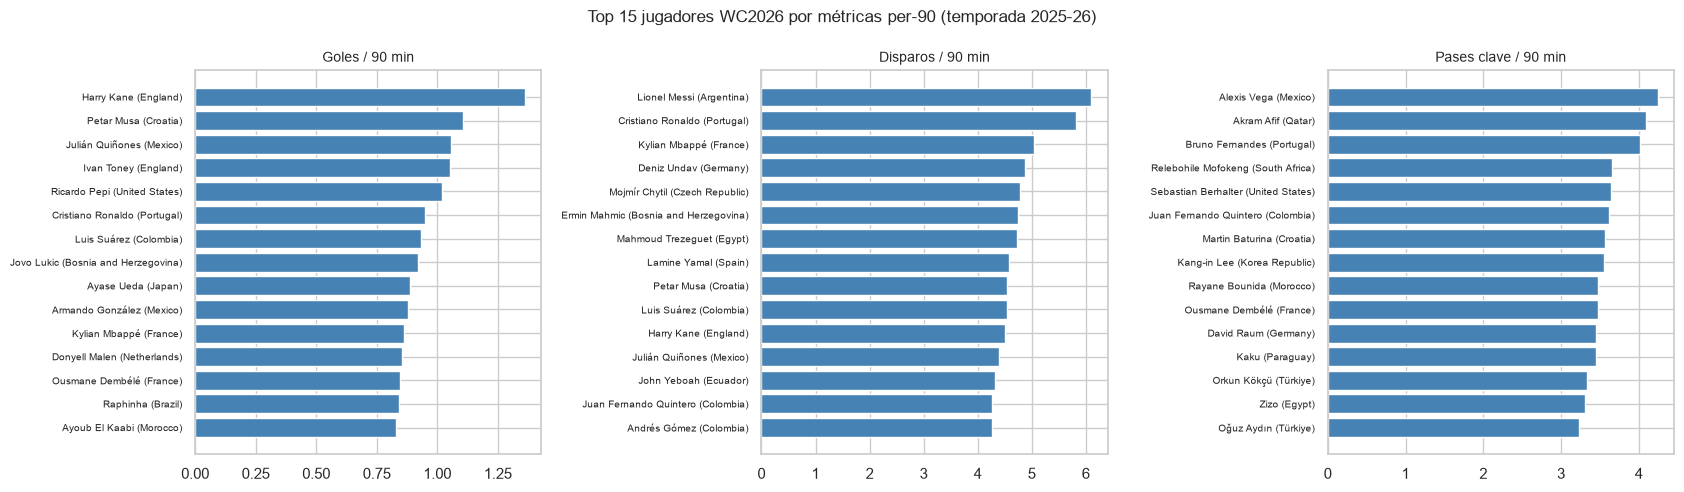


Top 20 por goals_per90:
             player_name              team_name position  minutes  goals_per90  shots_per90  assists_per90  rating
              Harry Kane                England       FW     2379        1.362        4.502          0.189    7.87
              Petar Musa                Croatia       FW      812        1.108        4.540          0.111    7.60
         Julián Quiñones                 Mexico       FW     2474        1.055        4.400          0.109    7.82
              Ivan Toney                England       FW     2390        1.054        2.940          0.226    7.41
            Ricardo Pepi          United States       FW     1413        1.019        3.885          0.064    7.22
       Cristiano Ronaldo               Portugal       FW     2275        0.949        5.820          0.079    7.55
             Luis Suárez               Colombia       FW     2700        0.933        4.533          0.200    7.52
              Jovo Lukic Bosnia and Herzegovina       F

In [11]:
# Top jugadores por métrica — goals_per90 como proxy de xG (no existe xG en este dataset)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, label in [
    (axes[0], 'goals_per90',      'Goles / 90 min'),
    (axes[1], 'shots_per90',      'Disparos / 90 min'),
    (axes[2], 'key_passes_per90', 'Pases clave / 90 min'),
]:
    if col not in per90_enriched.columns:
        continue
    top = (per90_enriched[per90_enriched[col].notna()]
           .sort_values(col, ascending=False)
           .head(15))
    # pd.isna() en lugar de "or '?'" para manejar float NaN correctamente
    labels = top.apply(
        lambda r: f"{r['player_name']} ({r['team_name'] if pd.notna(r['team_name']) else '?'})",
        axis=1
    )
    ax.barh(labels, top[col], color='steelblue')
    ax.set_title(label, fontsize=10)
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Top 15 jugadores WC2026 por métricas per-90 (temporada 2025-26)', fontsize=12)
plt.tight_layout()
plt.show()

# Tabla top 20 goals_per90 con contexto completo
print("\nTop 20 por goals_per90:")
cols_show = ['player_name', 'team_name', 'position', 'minutes',
             'goals_per90', 'shots_per90', 'assists_per90', 'rating']
cols_show = [c for c in cols_show if c in per90_enriched.columns]
top20 = (per90_enriched[per90_enriched['goals_per90'].notna()]
         .sort_values('goals_per90', ascending=False)
         .head(20)[cols_show])
print(top20.to_string(index=False))

## 7. Cobertura en mart_player_scouting

In [12]:
# mart_player_scouting es StatsBomb-only: one row per (player × competition_slug)
# Rising Transfers players que NO aparecen en StatsBomb NO están en el mart.
# El LIMIT + ORDER BY xg_per90 DESC anterior solo devolvía StatsBomb — corregido aquí.

# 1) Totales sin LIMIT
cov = query("""
    SELECT
        COUNT(*)                         AS total_registros,
        COUNT(DISTINCT player_name)      AS jugadores_unicos,
        COUNT(DISTINCT team_canonical)   AS equipos_distintos
    FROM gold.mart_player_scouting
""")
print("=== mart_player_scouting (sin LIMIT) ===")
print(f"Registros totales (player × competition): {cov['total_registros'].iloc[0]:,}")
print(f"Jugadores únicos:                         {cov['jugadores_unicos'].iloc[0]:,}")
print(f"Equipos distintos (incluye no-WC2026):    {cov['equipos_distintos'].iloc[0]}")

# 2) ¿Cuántos jugadores de squads WC2026 tienen match en el mart (datos StatsBomb)?
# Usamos rt_position/rt_market_value_eur como señal de que el jugador estaba en squads
cov_wc = query("""
    SELECT
        CASE WHEN rt_position IS NOT NULL THEN 'WC2026 plantel + StatsBomb'
             ELSE 'Solo StatsBomb (no en WC2026 squads)'
        END AS categoria,
        COUNT(DISTINCT player_name) AS jugadores,
        COUNT(DISTINCT team_canonical) AS equipos
    FROM gold.mart_player_scouting
    GROUP BY 1
    ORDER BY jugadores DESC
""")
print("\nCobertura cruzada squads WC2026 × StatsBomb:")
print(cov_wc.to_string(index=False))

# 3) Top 10 por xg_per90 — un registro por jugador (mejor competición)
top_xg = query("""
    SELECT DISTINCT ON (player_name)
        player_name, team_canonical, competition_slug, matches, xg_per90, goals_per90
    FROM gold.mart_player_scouting
    WHERE xg_per90 IS NOT NULL
    ORDER BY player_name, xg_per90 DESC
""")
print(f"\nJugadores únicos con xg_per90 en StatsBomb: {len(top_xg)}")
print("\nTop 10 por xg_per90 (mejor competición por jugador):")
print(top_xg.sort_values('xg_per90', ascending=False)
      .head(10)[['player_name', 'team_canonical', 'competition_slug', 'matches', 'xg_per90', 'goals_per90']]
      .to_string(index=False))

=== mart_player_scouting (sin LIMIT) ===
Registros totales (player × competition): 2,002
Jugadores únicos:                         1,504
Equipos distintos (incluye no-WC2026):    56

Cobertura cruzada squads WC2026 × StatsBomb:
                           categoria  jugadores  equipos
Solo StatsBomb (no en WC2026 squads)       1257       56
          WC2026 plantel + StatsBomb        247       28

Jugadores únicos con xg_per90 en StatsBomb: 1504

Top 10 por xg_per90 (mejor competición por jugador):
                        player_name team_canonical competition_slug  matches  xg_per90  goals_per90
Cristiano Ronaldo dos Santos Aveiro       Portugal        euro_2020        4     1.216        1.250
     Lionel Andrés Messi Cuccittini      Argentina           wc2022        7     1.086        1.286
                       Mislav Oršić        Croatia        euro_2020        1     1.034        1.000
               Pablo Sarabia García          Spain           wc2022        1     0.888        0.0

## 8. Hallazgos

### stg_wc2026_squads (Rising Transfers)
| Métrica | Valor | Notas |
|---------|-------|-------|
| Total jugadores | 1,363 | 48 equipos × 28.4 promedio |
| Nulos market_value_eur | 46 (3.4%) | Jugadores de ligas menores / sin ficha |
| Nulos age | 7 (0.5%) | Normal, aceptable |
| Nulos club | 8 (0.6%) | Normal, aceptable |

### stg_wc2026_per90 (Rising Transfers)
| Métrica | Valor | Notas |
|---------|-------|-------|
| Total jugadores con per90 | 1,181 | ~87% del plantel activo en 2025-26 |
| Nulos rating | 48 (4.1%) | Rating Sofascore, menos cobertura |
| Nulos pass_accuracy_pct | 21 (1.8%) | GKs con muy pocos pases |
| Join match rate squads↔per90 | 100.0% | Nombres consistentes entre CSVs de RT |

### Posiciones (códigos cortos Rising Transfers)
Los valores son `GK`, `DF`, `MF`, `FW` — **no** nombres expandidos como `'Goalkeeper'`.
El `pos_map` debe usar estos códigos.

### Duplicados en merge per90 → squads
Al menos 4 jugadores en per90 tenían el mismo nombre que otro jugador en squads de equipo
diferente (homónimos), creando 1,185 filas desde 1,181 jugadores. Solución:
`drop_duplicates(subset=['player_name'], keep='first')` en squads antes del merge → 1181/1181.

### mart_player_scouting — cobertura cruzada
| Categoría | Jugadores únicos | Equipos |
|-----------|-----------------|---------|
| WC2026 plantel + datos StatsBomb históricos | 247 | 28 |
| Solo StatsBomb (jugadores no en WC2026) | 1,257 | 56 |

Los **247 jugadores** son los únicos del plantel actual que aparecen en eventos StatsBomb
(WC2022, Copa América 2024, Euro 2020/2024). Los 28 equipos son los que tienen al menos
un jugador con cobertura individual de eventos — distinto de los 34 del notebook 03, donde
el conteo es a nivel de *equipo en partido* (no de jugador individual en plantel actual).

**Implicación para Monte Carlo:** para los λ de equipo se usan los 34 equipos del notebook 04
(xG promedio por partido en StatsBomb). Los 247 jugadores individuales aquí son útiles para
scouting pero no se agregan por equipo directamente.